In [566]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [567]:
#Load the dataset
df=pd.read_csv("/content/AB_NYC_2019.csv")

In [568]:
#basic data insepction
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [569]:
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


In [570]:
print(df.shape)

(48895, 16)


In [571]:
print(df.columns)

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')


In [572]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [573]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [574]:
# Numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
print("Numerical Columns:",numerical_columns)

Numerical Columns: Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')


In [575]:
# Categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns
print("Categorical Columns:",categorical_columns)

Categorical Columns: Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='object')


In [576]:
#Check the missing values
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [577]:
#To calculate percentage of missing values
(df.isnull().sum()/len(df))*100

,0
id,0.000000
name,0.032723
host_id,0.000000
host_name,0.042949
neighbourhood_group,0.000000
neighbourhood,0.000000
latitude,0.000000
longitude,0.000000
room_type,0.000000
price,0.000000


In [578]:
#Handle the missing values
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [579]:
# Drop last_review
df = df.drop(columns=["last_review"])

In [580]:
#Drop the uncessary columns
df = df.drop( columns=["id","name","host_id","host_name"])

In [581]:
#Checking again missing values
df.isnull().sum()

,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
calculated_host_listings_count,0


In [582]:
#Checking duplicates values present
df.duplicated().sum()

np.int64(0)

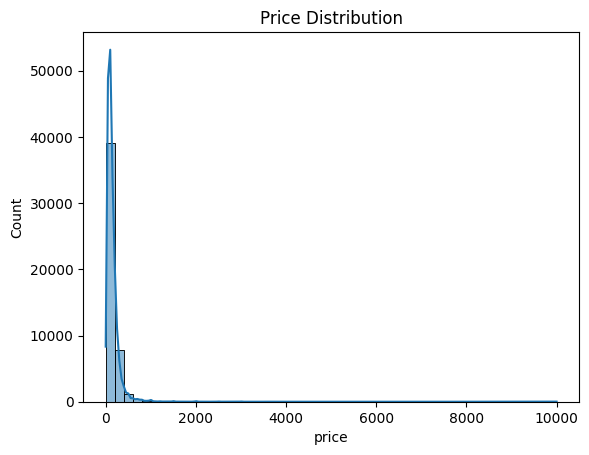

In [583]:
#Univaraite Analysis-Price distribution
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

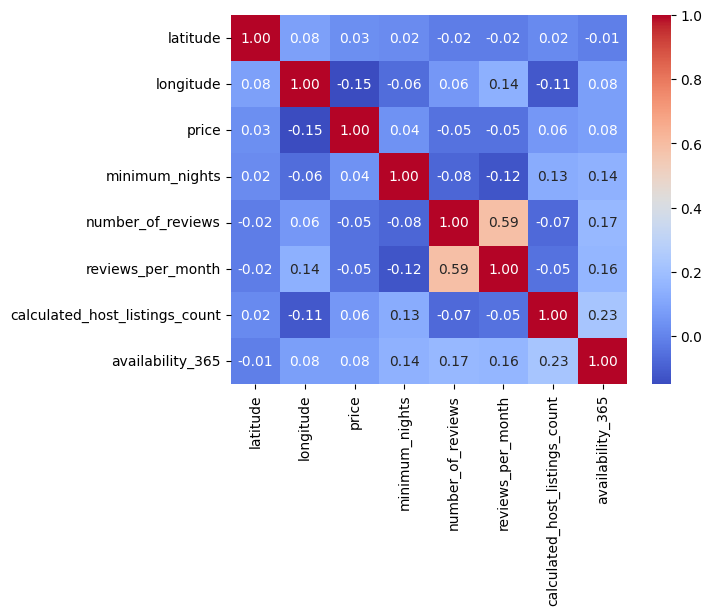

In [584]:
#correlation heatmap
numeric_df = df.select_dtypes(include = np.number)#works only in numeric
corr = numeric_df.corr()
sns.heatmap(corr, annot = True,cmap = "coolwarm",fmt = ".2f")#cmap-colours,fmt=after numeric values hiw much decimal must be
plt.show()

Text(0.5, 1.0, 'Price Outliers')

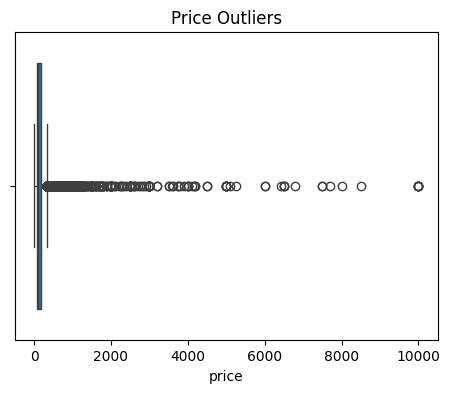

In [585]:
#Outliers
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df["price"])
plt.title("Price Outliers")


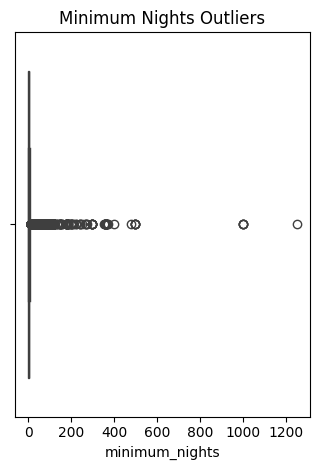

In [586]:
plt.subplot(1, 2, 2)
sns.boxplot(x=df["minimum_nights"])
plt.title("Minimum Nights Outliers")
plt.tight_layout()
plt.show()

In [587]:
#Check dataset size before treatment
print("Before:", df.shape)

Before: (48895, 11)


In [588]:
#Remove extreme price values
price_limit = df["price"].quantile(0.95)
df = df[df["price"] <= price_limit]

In [589]:
#Remove very high minimum-night values
df = df[df["minimum_nights"] < 365]

In [590]:
#Check dataset size after treatment
print("After:", df.shape)

After: (46417, 11)


Text(0.5, 1.0, 'Price After Treatment')

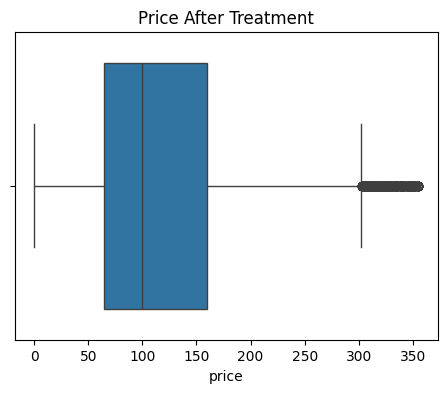

In [591]:
#verfiy the boxplots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df["price"])
plt.title("Price After Treatment")

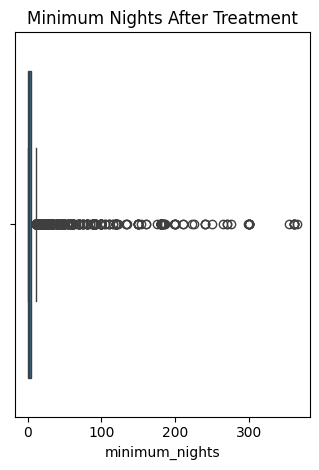

In [592]:
plt.subplot(1, 2, 2)
sns.boxplot(x=df["minimum_nights"])
plt.title("Minimum Nights After Treatment")
plt.tight_layout()
plt.show()

Outliers were treated using the 95th-percentile method for the price column. Listings with prices above the 95th percentile were removed. Listings with minimum stays of 365 nights or more were also removed. This reduced the influence of extreme values and made the dataset more suitable for Linear Regression.

In [593]:
#Check unique values
print("Neighbourhood:",df["neighbourhood"].nunique())
print("Neighbourhood Group:",df["neighbourhood_group"].nunique())

Neighbourhood: 219
Neighbourhood Group: 5


In [594]:
#Drop neighbourhood
df = df.drop(columns=["neighbourhood"])

The neighbourhood column contained more than 200 unique categories. One-Hot Encoding this column would create a large number of additional features and increase the complexity of the model. Therefore, the neighbourhood column was dropped. The neighbourhood_group column was retained because it contains only five categories and can be encoded efficiently.


In [595]:
#Check the updated dataset
print(df.columns)

Index(['neighbourhood_group', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')


In [596]:
#converting text into numerical
object_cols=df.select_dtypes(include='object').columns#give me only object columns
print(object_cols)

Index(['neighbourhood_group', 'room_type'], dtype='object')


In [597]:
#One-Hot Encoding
df = pd.get_dummies(df,columns=["neighbourhood_group","room_type"],drop_first=True)

In [598]:
#Check the datatypes
df.dtypes

,0
latitude,float64
longitude,float64
price,int64
minimum_nights,int64
number_of_reviews,int64
reviews_per_month,float64
calculated_host_listings_count,int64
availability_365,int64
neighbourhood_group_Brooklyn,bool
neighbourhood_group_Manhattan,bool


In [599]:
#Check whether all columns are numerical
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [600]:
#Import libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [601]:
#Separate Features (X) and Target (y)
X = df.drop(columns=["price"])
y = df["price"]

In [602]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (46417, 13)
y shape: (46417,)


In [603]:
#Train-Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [604]:
#Check the shapes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(37133, 13)
(9284, 13)
(37133,)
(9284,)


In [605]:
#Initialize the model
model=LinearRegression()

In [606]:
#Train the model
model.fit(X_train,y_train)

LinearRegression()

In [607]:
#finding intercept value
print("Intercept value:",model.intercept_)

Intercept value: -17898.330446790027


In [608]:
#check coefficients
coefficient_table = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coefficient_table

,Coefficient
latitude,-78.370738
longitude,-287.255169
minimum_nights,-0.444826
number_of_reviews,-0.055164
reviews_per_month,-0.584145
calculated_host_listings_count,0.099942
availability_365,0.066873
neighbourhood_group_Brooklyn,-7.854108
neighbourhood_group_Manhattan,23.945688
neighbourhood_group_Queens,5.192307


In [609]:
y_pred = model.predict(X_test)

In [610]:
#View the first 5 predictions
print(y_pred[:5])

[ 76.07714099 154.08859994  84.77060267  70.7688319   64.87323   ]


In [611]:
#Compare Actual vs Predicted Prices
results=pd.DataFrame({'Actual':y_test.values,'Predicted':y_pred})
results["Difference"]=results["Actual"]-results["Predicted"]
results.head(10)

,Actual,Predicted,Difference
0,55,76.077141,-21.077141
1,180,154.088600,25.911400
2,50,84.770603,-34.770603
3,45,70.768832,-25.768832
4,70,64.873230,5.126770
5,40,71.152507,-31.152507
6,45,53.691144,-8.691144
7,175,152.386632,22.613368
8,145,132.519283,12.480717
9,45,63.435491,-18.435491


In [612]:
#Model Evaluation
mae =mean_absolute_error(y_test,y_pred)
mse =mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
rmse=np.sqrt(mse)

In [613]:
print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("R-Squared:",r2)
print("Root Mean Squared Error:",rmse)

Mean Absolute Error: 37.97321332017245
Mean Squared Error: 2725.0457552756634
R-Squared: 0.47155122844020847
Root Mean Squared Error: 52.20197079877026


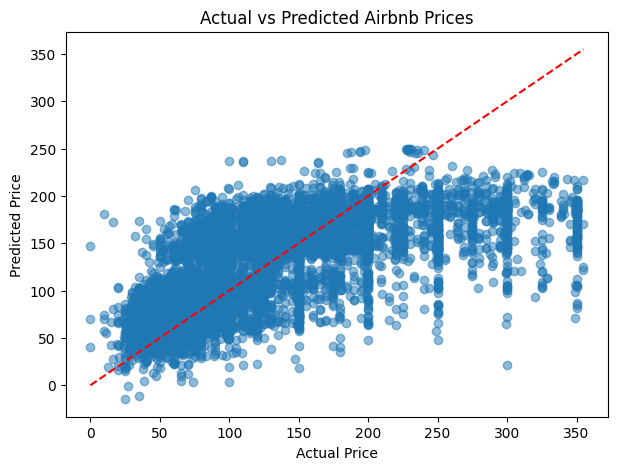

In [614]:
#Actual Price vs. Predicted Price Plot
plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred,alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],"r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices")
plt.show()

In [615]:
residuals = y_test - y_pred

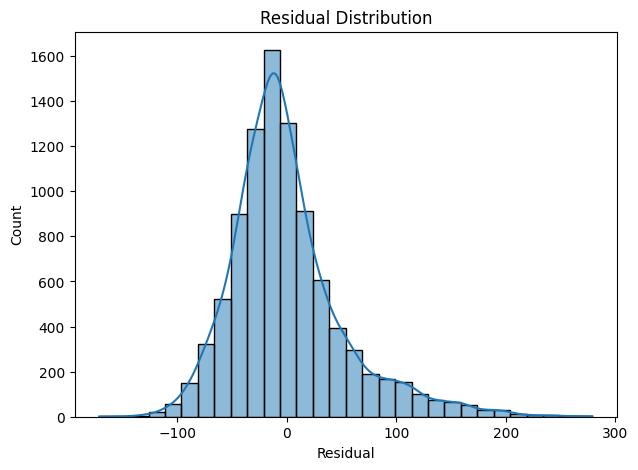

In [616]:
#Error Distribution Histogram
plt.figure(figsize=(7, 5))
sns.histplot(residuals,bins=30,kde=True)
plt.xlabel("Residual")
plt.title("Residual Distribution")
plt.show()

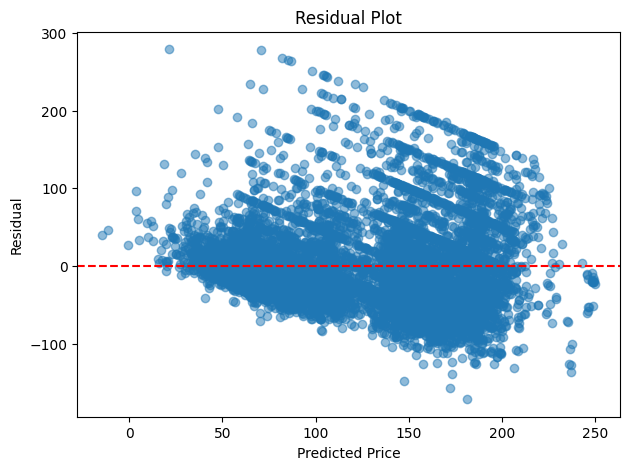

In [617]:
#Residual Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_pred,residuals,alpha=0.5)
plt.axhline(y=0,color="red",linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [618]:
#Createing a comparison DataFrame
results = pd.DataFrame({"Actual": y_test.values,"Predicted": y_pred})
results["Error"] = abs(results["Actual"] -results["Predicted"])
results.head()

,Actual,Predicted,Error
0,55,76.077141,21.077141
1,180,154.088600,25.911400
2,50,84.770603,34.770603
3,45,70.768832,25.768832
4,70,64.873230,5.126770


In [619]:
#Divide listings into cheap and expensive
median_price = results["Actual"].median()
cheap = results[results["Actual"] <= median_price]
expensive = results[results["Actual"] > median_price]

In [620]:
#Compare average errors
print("Cheap Listing MAE:",cheap["Error"].mean())
print("Expensive Listing MAE:",expensive["Error"].mean())

Cheap Listing MAE: 28.753309674148134
Expensive Listing MAE: 47.96713356857903
